In [ ]:
from pathlib import Path
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import cv2
import re
from itertools import combinations
import numpy as np
import pandas as pd


USER = "meryv"
video_folder = Path("/Users") / USER / "Desktop" / "sleap" / "clean"

feather_folder = (
    Path("/Users") / USER / "Desktop" / "sleap" / "csv-tofeather"
)
feather_files = sorted(feather_folder.glob("*.tracks.feather"))

perimeters_file = (
    Path("/Users") / USER / "repos" / "sensory-deprivation" / "perimeters" / "perimeter_centres.csv"
)
perimeters_folder = (
    Path("/Users") / USER / "repos" / "sensory-deprivation" / "perimeters" )

CONDITIONS = ["W1118", "anosmic", "23129", "33300", "9047"]
REFERENCE = "W1118"
NODE_PARTS = ["head", "body", "tail"]
INTERACTION_TYPES = [
    ("head", "head"),
    ("body", "body"), 
    ("tail", "tail"), 
    ("head", "tail"),
    ("head", "body"),
    ("body", "tail"), 
]

data_by_condition = {condition: [] for condition in CONDITIONS}
files_by_condition = {condition: [] for condition in CONDITIONS}

print(f"Found {len(feather_files)} feather files total.")

Found 14 feather files total.


In [139]:
centre_df = pd.read_csv(perimeters_file)

# Clean column names just in case
centre_df.columns = centre_df.columns.str.strip()

# Clean matching keys
centre_df["matching_key"] = centre_df["matching_key"].astype(str).str.strip()

centre_lookup = {
    row["matching_key"]: row
    for _, row in centre_df.iterrows()
}

print(f"Loaded {len(centre_lookup)} perimeter keys.")
print(list(centre_lookup.keys())[:5])


Loaded 15 perimeter keys.
['2026-03-20_td3_23129', '2026-03-20_td18_W1118', '2026-03-20_td19_W1118', '2026-03-23_td2_23129', '2026-03-23_td5_33300']


In [140]:
import re


def make_matching_key(filename):
    """
    Extract a stable key from video or feather filenames.

    Examples:
    2026-03-20_12-15-57_td18_W1118.mp4
        -> 2026-03-20_td18_W1118

    2026-03-20_td18_W1118.tracks.feather
        -> 2026-03-20_td18_W1118
    """

    name = str(filename)

    # Remove path if present
    name = name.split("/")[-1]

    # Remove extensions / suffixes
    name = name.replace(".tracks.feather", "")
    name = name.replace(".mp4", "")

    # Remove time if present, e.g. _12-15-57
    name = re.sub(r"_\d{2}-\d{2}-\d{2}", "", name)

    # Extract date, td number, and condition
    pattern = r"(\d{4}-\d{2}-\d{2}).*(td\d+).*?(W1118|anosmic|23129|33300|9047)"

    match = re.search(pattern, name, flags=re.IGNORECASE)

    if match is None:
        return None

    date = match.group(1)
    td_number = match.group(2)
    condition = match.group(3)

    # Keep W1118 casing consistent
    for known_condition in CONDITIONS:
        if condition.lower() == known_condition.lower():
            condition = known_condition
            break

    return f"{date}_{td_number}_{condition}"

In [141]:
data_by_condition = {condition: [] for condition in CONDITIONS}
files_by_condition = {condition: [] for condition in CONDITIONS}

for feather_file in feather_files:
    filename = feather_file.name
    matching_key = make_matching_key(filename)

    if matching_key is not None:
        matching_key = matching_key.strip()

    matched_condition = None

    for condition in CONDITIONS:
        if condition.lower() in filename.lower():
            matched_condition = condition
            break

    if matched_condition is None:
        print(f"Skipping file with no recognised condition: {filename}")
        continue

    df = pd.read_feather(feather_file)
    df = df[df["frame"] <= 3599].copy()

    df["file"] = filename
    df["matching_key"] = matching_key
    df["condition"] = matched_condition

    if matching_key not in centre_lookup:
        print(f"No perimeter centre data found for: {filename}")
        print(f"Matching key was: {matching_key}")
        print("Keeping only original pixel coordinates for this file.")

    else:
        centre_row = centre_lookup[matching_key]

        centre_x = float(centre_row["centre_x"])
        centre_y = float(centre_row["centre_y"])
        mm_per_pixel = float(centre_row["mm_per_pixel"])

        df["video_file"] = centre_row["video_file"]
        df["centre_x"] = centre_x
        df["centre_y"] = centre_y
        df["mm_per_pixel"] = mm_per_pixel
        df["diameter_pixels"] = float(centre_row["diameter"])

        for part in ["head", "body", "tail"]:
            df[f"x_{part}_centred_px"] = df[f"x_{part}"] - centre_x
            df[f"y_{part}_centred_px"] = df[f"y_{part}"] - centre_y

            df[f"x_{part}_mm"] = df[f"x_{part}_centred_px"] * mm_per_pixel
            df[f"y_{part}_mm"] = df[f"y_{part}_centred_px"] * mm_per_pixel

        print(
            f"MATCHED: {filename} -> {centre_row['video_file']} "
            f"key={matching_key}, "
            f"mm_per_pixel={mm_per_pixel:.5f}"
        )

    data_by_condition[matched_condition].append(df)
    files_by_condition[matched_condition].append(feather_file)

MATCHED: 2026-03-20_td18_W1118.tracks.feather -> 2026-03-20_12-15-57_td18_W1118.mp4 key=2026-03-20_td18_W1118, mm_per_pixel=0.08728
MATCHED: 2026-03-20_td19_W1118.tracks.feather -> 2026-03-20_12-17-07_td19_W1118.mp4 key=2026-03-20_td19_W1118, mm_per_pixel=0.09363
MATCHED: 2026-03-20_td3_23129.tracks.feather -> 2026-03-20_11-36-47_td3_23129.mp4 key=2026-03-20_td3_23129, mm_per_pixel=0.08662
MATCHED: 2026-03-23_td16_33300.tracks.feather -> 2026-03-23_12-18-46_td16_33300.mp4 key=2026-03-23_td16_33300, mm_per_pixel=0.08594
MATCHED: 2026-03-23_td2_23129.tracks.feather -> 2026-03-23_11-38-40_td2_23129.mp4 key=2026-03-23_td2_23129, mm_per_pixel=0.08767
MATCHED: 2026-03-31_td11_9047.tracks.feather -> 2026-03-31_12-08-02_td11_9047.mp4 key=2026-03-31_td11_9047, mm_per_pixel=0.08634
MATCHED: 2026-03-31_td3_9047.tracks.feather -> 2026-03-31_11-44-00_td3_9047.mp4 key=2026-03-31_td3_9047, mm_per_pixel=0.08672
MATCHED: 2026-03-31_td4_23129.tracks.feather -> 2026-03-31_11-47-00_td4_23129.mp4 key=2026-

In [142]:
combined_conditions = {
    condition: pd.concat(dfs, ignore_index=True) if len(dfs) > 0 else pd.DataFrame()
    for condition, dfs in data_by_condition.items()
}

df_w1118 = combined_conditions["W1118"]
df_anosmic = combined_conditions["anosmic"]
df_23129 = combined_conditions["23129"]
df_33300 = combined_conditions["33300"]
df_9047 = combined_conditions["9047"]

How far are the larva from the centre of the plate?

In [150]:
def calculate_distance_from_centre(df):
    """
    Since x_body_mm and y_body_mm are centred around the dish centre:
    distance from centre = sqrt(x_body_mm^2 + y_body_mm^2)
    """

    df = df.copy()

    df["distance_from_centre"] = np.sqrt(
        df["x_body_mm"] ** 2
        + df["y_body_mm"] ** 2
    )

    return df

for condition in CONDITIONS:
    if not combined_conditions[condition].empty:
        combined_conditions[condition] = calculate_distance_from_centre(
            combined_conditions[condition]
        )

distance_from_centre_df = pd.concat(
    [
        df[
            [
                "condition",
                "file",
                "frame",
                "track_id",
                "distance_from_centre",
            ]
        ]
        for df in combined_conditions.values()
        if not df.empty
    ],
    ignore_index=True,
)

distance_video_summary = (
    distance_from_centre_df
    .groupby(["condition", "file"])["distance_from_centre"]
    .mean()
    .reset_index(name="mean_distance_from_centre")
)

distance_condition_summary = (
    distance_video_summary
    .groupby("condition")["mean_distance_from_centre"]
    .agg(["mean", "std", "sem", "count"])
    .reset_index()
    .set_index("condition")
    .loc[CONDITIONS]
    .reset_index()
)

distance_video_summary

,condition,file,mean_distance_from_centre
0,23129,2026-03-20_td3_23129.tracks.feather,35.256281
1,23129,2026-03-23_td2_23129.tracks.feather,38.385398
2,23129,2026-03-31_td4_23129.tracks.feather,34.341270
3,33300,2026-03-23_td16_33300.tracks.feather,36.680195
4,33300,2026-03-31_td6_33300.tracks.feather,38.117692
5,9047,2026-03-31_td11_9047.tracks.feather,34.015299
6,9047,2026-03-31_td3_9047.tracks.feather,35.411030
7,9047,2026-04-14_td6_9047.tracks.feather,35.701528
8,W1118,2026-03-20_td18_W1118.tracks.feather,36.926058
9,W1118,2026-03-20_td19_W1118.tracks.feather,39.135745


Next step: find euclidean distance - how far are they from each other?

In [152]:
%pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 102.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [153]:
from scipy.spatial.distance import cdist
import numpy as np
import pandas as pd


def calculate_euclidean_distance_per_frame(df):
    """
    Calculate average pairwise body-body distance between larvae per frame.

    Uses:
        x_body_mm, y_body_mm

    Output:
        one row per video per frame
    """

    data = []

    for file_name, df_video in df.groupby("file"):

        for frame, frame_df in df_video.groupby("frame"):

            frame_df = frame_df.dropna(
                subset=["x_body_mm", "y_body_mm"]
            )

            if frame_df["track_id"].nunique() < 2:
                continue

            body_coordinates = frame_df[
                ["x_body_mm", "y_body_mm"]
            ].to_numpy()

            distance_matrix = cdist(
                body_coordinates,
                body_coordinates,
                metric="euclidean",
            )

            np.fill_diagonal(distance_matrix, np.nan)

            average_distance = np.nanmean(distance_matrix)

            data.append({
                "condition": frame_df["condition"].iloc[0],
                "file": file_name,
                "frame": frame,
                "average_pairwise_distance": average_distance,
                "n_larvae": frame_df["track_id"].nunique(),
            })

    euclidean_distance_df = pd.DataFrame(data)

    euclidean_distance_df = euclidean_distance_df.sort_values(
        ["condition", "file", "frame"]
    ).reset_index(drop=True)

    return euclidean_distance_df

In [155]:
all_tracking_data = pd.concat(
    [
        df for df in combined_conditions.values()
        if not df.empty
    ],
    ignore_index=True,
)

euclidean_distance_df = calculate_euclidean_distance_per_frame(
    all_tracking_data
)

euclidean_distance_df

,condition,file,frame,average_pairwise_distance,n_larvae
0,23129,2026-03-20_td3_23129.tracks.feather,0,4.767781,5
1,23129,2026-03-20_td3_23129.tracks.feather,1,5.844077,5
2,23129,2026-03-20_td3_23129.tracks.feather,2,6.812238,5
3,23129,2026-03-20_td3_23129.tracks.feather,3,8.247351,5
4,23129,2026-03-20_td3_23129.tracks.feather,4,9.507652,5
...,...,...,...,...,...
50395,anosmic,2026-06-26_td6_anosmic.tracks.feather,3595,43.643517,5
50396,anosmic,2026-06-26_td6_anosmic.tracks.feather,3596,43.664528,5
50397,anosmic,2026-06-26_td6_anosmic.tracks.feather,3597,43.706782,5
50398,anosmic,2026-06-26_td6_anosmic.tracks.feather,3598,43.551385,5


In [156]:
euclidean_video_summary = (
    euclidean_distance_df
    .groupby(["condition", "file"])["average_pairwise_distance"]
    .mean()
    .reset_index(name="mean_pairwise_distance")
)

euclidean_video_summary

,condition,file,mean_pairwise_distance
0,23129,2026-03-20_td3_23129.tracks.feather,42.606781
1,23129,2026-03-23_td2_23129.tracks.feather,41.866646
2,23129,2026-03-31_td4_23129.tracks.feather,46.609925
3,33300,2026-03-23_td16_33300.tracks.feather,46.110470
4,33300,2026-03-31_td6_33300.tracks.feather,49.834436
5,9047,2026-03-31_td11_9047.tracks.feather,44.303385
6,9047,2026-03-31_td3_9047.tracks.feather,44.684085
7,9047,2026-04-14_td6_9047.tracks.feather,46.521359
8,W1118,2026-03-20_td18_W1118.tracks.feather,47.162931
9,W1118,2026-03-20_td19_W1118.tracks.feather,44.087288


In [158]:
combined_video_spatial_summary = euclidean_video_summary.merge(
    distance_video_summary,
    on=["condition", "file"],
    how="left",
)

euclidean_condition_summary = (
    euclidean_video_summary
    .groupby("condition")["mean_pairwise_distance"]
    .agg(["mean", "std", "sem", "count"])
    .reset_index()
    .set_index("condition")
    .loc[CONDITIONS]
    .reset_index()
)

euclidean_condition_summary

,condition,mean,std,sem,count
0,W1118,44.488901,2.497560,1.441967,3
1,anosmic,42.650949,2.244527,1.295878,3
2,23129,43.694451,2.551851,1.473312,3
3,33300,47.972453,2.633242,1.861983,2
4,9047,45.169610,1.186024,0.684751,3


Delete

In [143]:
def interaction_name(part_a, part_b):
    """
    Make interaction names consistent.
    For example, body-tail and tail-body both become body_tail.
    """
    return "_".join(sorted([part_a, part_b]))

CONTACT_THRESHOLD = 1.0      # <1 mm node-node contact
APPROACH_DISTANCE = 10.0     # threshold for them approaching... 
APPROACH_LOOKBACK = 60       # frames before contact to inspect
MIN_BOUT_FRAMES = 1          # ignore 1-frame contacts if you want stricter bouts
coord_suffix = "_mm"

# Condition-level summary
condition_summary = pd.DataFrame({
    "condition": list(combined_conditions.keys()),
    "n_rows": [len(df) for df in combined_conditions.values()],
    "n_videos": [
        df["file"].nunique() if "file" in df.columns and not df.empty else 0
        for df in combined_conditions.values()
    ],
})

condition_summary

,condition,n_rows,n_videos
0,W1118,54000,3
1,anosmic,53970,3
2,23129,54000,3
3,33300,36000,2
4,9047,53982,3


In [ ]:
def tracks(self):
    # 2024-04-30_14-31-44_td5.000_2024-04-30_14-31-44_td5.analysis.csv
    self.track_files = [f for f in os.listdir(self.directory) if f.endswith('tracks.feather')]
    
    for track_file in self.track_files: 
        track_path = os.path.join(self.directory, track_file)
        df = pd.read_feather(track_path)
            # NEED DIAMATER CONVERSION FFS 
            # # cant access the perimeter right now here 
            # diameter = self.diameter()
            # print(diameter)

            # pixels_to_mm = ['x_tail', 'y_tail', 'x_body', 'y_body', 'x_head', 'y_head']
            # df[pixels_to_mm] = df[pixels_to_mm] * (90 / diameter)
            # print(df.head())
        self.track_data[track_file] = df

def classify_interaction_type(node_a, node_b):
    """
    Makes interaction labels symmetrical:
    head_body and body_head both become body_head.
    """

    if node_a is None or node_b is None:
        return None

    return "_".join(sorted([node_a, node_b]))

def euclidean_distance(x1, y1, x2, y2):
    return np.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

def label_contact_bouts(pair_df, contact_threshold=1.0, min_bout_frames=2):
    """
    Detects continuous bouts where a larva pair is within <1 mm
    based on the minimum node-node distance.

    One bout = same larva pair, consecutive frames, min_node_distance < threshold.
    """

    bouts = []

    if pair_df.empty:
        return pd.DataFrame()

    pair_df = pair_df.copy()
    pair_df = pair_df.sort_values(["track_a", "track_b", "frame"])

    bout_id = 0

    for (track_a, track_b), group in pair_df.groupby(["track_a", "track_b"]):

        group = group.sort_values("frame").reset_index(drop=True)
        in_bout = False
        current_rows = []

        for _, row in group.iterrows():

            is_contact = row["min_node_distance"] < contact_threshold

            if is_contact and not in_bout:
                in_bout = True
                current_rows = [row]

            elif is_contact and in_bout:
                previous_frame = current_rows[-1]["frame"]

                if row["frame"] == previous_frame + 1:
                    current_rows.append(row)
                else:
                    if len(current_rows) >= min_bout_frames:
                        bouts.append((bout_id, current_rows))
                        bout_id += 1

                    current_rows = [row]

            elif not is_contact and in_bout:
                if len(current_rows) >= min_bout_frames:
                    bouts.append((bout_id, current_rows))
                    bout_id += 1

                current_rows = []
                in_bout = False

        if in_bout and len(current_rows) >= min_bout_frames:
            bouts.append((bout_id, current_rows))
            bout_id += 1

    bout_rows = []

    for bout_id, rows in bouts:
        bout_df = pd.DataFrame(rows)

        bout_rows.append({
            "bout_id": bout_id,
            "track_a": bout_df["track_a"].iloc[0],
            "track_b": bout_df["track_b"].iloc[0],
            "start_frame": bout_df["frame"].min(),
            "end_frame": bout_df["frame"].max(),
            "duration_frames": bout_df["frame"].max() - bout_df["frame"].min() + 1,
            "min_distance": bout_df["min_node_distance"].min(),
            "mean_distance": bout_df["min_node_distance"].mean(),
            "initial_interaction_type": bout_df["interaction_type"].iloc[0],
            "predominant_interaction_type": bout_df["interaction_type"].mode().iloc[0],
        })

    return pd.DataFrame(bout_rows)

def make_pairwise_node_distance_table(df):
    """
    Creates one row per larva pair per frame.
    Includes minimum node-node distance and closest node pair.
    """

    pair_rows = []

    df = df.copy()
    df = df.sort_values(["frame", "track_id"])

    for frame, frame_df in df.groupby("frame"):

        if frame_df["track_id"].nunique() < 2:
            continue

        rows = list(frame_df.iterrows())

        for (_, row_a), (_, row_b) in combinations(rows, 2):

            track_a = int(row_a["track_id"])
            track_b = int(row_b["track_id"])

            min_distance, node_a, node_b = min_node_distance_between_larvae(
                row_a,
                row_b,
            )

            interaction_type = classify_interaction_type(node_a, node_b)

            pair_rows.append({
                "frame": frame,
                "track_a": track_a,
                "track_b": track_b,
                "min_node_distance": min_distance,
                "node_a": node_a,
                "node_b": node_b,
                "interaction_type": interaction_type,
            })

    return pd.DataFrame(pair_rows)

def node_distance(row_a, row_b, part_a, part_b):
    """
    Node-node distance in mm.
    Requires x_head_mm, y_head_mm, etc.
    """

    return np.sqrt(
        (row_a[f"x_{part_a}_mm"] - row_b[f"x_{part_b}_mm"]) ** 2
        + (row_a[f"y_{part_a}_mm"] - row_b[f"y_{part_b}_mm"]) ** 2
    )


def calculate_video_interaction_probabilities(
    df,
    threshold=CONTACT_THRESHOLD,
    interaction_types=INTERACTION_TYPES,
):
    """
    Calculates node-node interaction probabilities for one video.

    Probability =
        number of contact pair-frames
        / total possible larva-pair frames

    For 5 larvae:
        10 larva pairs per frame
        3600 frames
        ~36,000 possible pair-frames per video
    """

    df = df.copy()
    df = df.sort_values(["frame", "track_id"])

    contact_counts = {
        interaction_name(part_a, part_b): 0
        for part_a, part_b in interaction_types
    }

    total_pair_frames = 0

    required_columns = {"frame", "track_id"}

    for part_a, part_b in interaction_types:
        required_columns.update([
            f"x_{part_a}_mm", f"y_{part_a}_mm",
            f"x_{part_b}_mm", f"y_{part_b}_mm",
        ])

    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        raise ValueError(f"Missing columns: {missing_columns}")

    for frame, frame_df in df.groupby("frame"):

        frame_df = frame_df.dropna(
            subset=list(required_columns - {"frame", "track_id"})
        )

        if frame_df["track_id"].nunique() < 2:
            continue

        larvae = list(frame_df.iterrows())

        for (_, row_a), (_, row_b) in combinations(larvae, 2):

            total_pair_frames += 1

            for part_a, part_b in interaction_types:

                name = interaction_name(part_a, part_b)

                if part_a == part_b:
                    distance = node_distance(row_a, row_b, part_a, part_b)

                else:
                    # Mixed contacts are symmetrical.
                    # body-head checks both:
                    # larva A body to larva B head
                    # larva A head to larva B body
                    distance_1 = node_distance(row_a, row_b, part_a, part_b)
                    distance_2 = node_distance(row_a, row_b, part_b, part_a)
                    distance = min(distance_1, distance_2)

                if distance < threshold:
                    contact_counts[name] += 1

    if total_pair_frames == 0:
        return {
            f"{name}_probability": np.nan
            for name in contact_counts
        }

    probabilities = {
        f"{name}_probability": count / total_pair_frames
        for name, count in contact_counts.items()
    }

    probabilities["total_pair_frames"] = total_pair_frames

    return probabilities
def angle_between_vectors(v1, v2):
    """
    Returns angle in degrees between two vectors.
    0 degrees = same direction.
    180 degrees = opposite direction.
    """

    v1 = np.asarray(v1, dtype=float)
    v2 = np.asarray(v2, dtype=float)

    if np.any(np.isnan(v1)) or np.any(np.isnan(v2)):
        return np.nan

    norm1 = np.linalg.norm(v1)
    norm2 = np.linalg.norm(v2)

    if norm1 == 0 or norm2 == 0:
        return np.nan

    cos_theta = np.dot(v1, v2) / (norm1 * norm2)
    cos_theta = np.clip(cos_theta, -1, 1)

    return np.degrees(np.arccos(cos_theta))


def body_heading_vector(row):
    """
    Vector pointing from body to head.
    This is the larva's body orientation / heading direction.
    """

    return np.array([
        row["x_head"] - row["x_body"],
        row["y_head"] - row["y_body"],
    ])


def movement_vector(row):
    """
    Vector of body movement between previous frame and current frame.
    Requires dx_body and dy_body columns.
    """

    return np.array([
        row["dx_body"],
        row["dy_body"],
    ])


def vector_to_partner(row_a, row_b, partner_node):
    """
    Vector from focal larva body to a node on the partner larva.
    """

    return np.array([
        row_b[f"x_{partner_node}"] - row_a["x_body"],
        row_b[f"y_{partner_node}"] - row_a["y_body"],
    ])



def add_body_kinematics(df):
    """
    Adds speed and acceleration per track based on body coordinates.
    Speed units are coordinate units per frame.
    If coordinates are in mm, speed is mm/frame.
    """

    df = df.copy()
    df = df.sort_values(["track_id", "frame"]).reset_index(drop=True)

    df["dx_body"] = df.groupby("track_id")["x_body"].diff()
    df["dy_body"] = df.groupby("track_id")["y_body"].diff()
    df["dt"] = df.groupby("track_id")["frame"].diff()

    df["speed"] = (
        np.sqrt(df["dx_body"] ** 2 + df["dy_body"] ** 2)
        / df["dt"]
    )

    # Remove impossible speed caused by frame gaps
    df.loc[(df["dt"] <= 0) | (df["dt"] > 2), "speed"] = np.nan

    df["acceleration"] = (
        df.groupby("track_id")["speed"].diff()
        / df.groupby("track_id")["dt"].transform(lambda x: x)
    )

    return df


def min_node_distance_between_larvae(row_a, row_b):
    """
    Finds the minimum distance across all 9 node-node combinations:
    head-head, head-body, head-tail, body-head, etc.

    Returns:
    - min_distance
    - node_a
    - node_b
    """

    best_distance = np.inf
    best_node_a = None
    best_node_b = None

    for node_a in NODE_PARTS:
        for node_b in NODE_PARTS:

            required_values = [
                row_a[f"x_{node_a}"], row_a[f"y_{node_a}"],
                row_b[f"x_{node_b}"], row_b[f"y_{node_b}"],
            ]

            if any(pd.isna(v) for v in required_values):
                continue

            distance = euclidean_distance(
                row_a[f"x_{node_a}"],
                row_a[f"y_{node_a}"],
                row_b[f"x_{node_b}"],
                row_b[f"y_{node_b}"],
            )

            if distance < best_distance:
                best_distance = distance
                best_node_a = node_a
                best_node_b = node_b

    if best_node_a is None:
        return np.nan, None, None

    return best_distance, best_node_a, best_node_b


def find_approach_window(pair_df, track_a, track_b, contact_start_frame):
    """
    Finds frames before a contact bout where the pair was approaching.

    Approach is defined here as:
    - frames before contact_start_frame
    - min_node_distance < APPROACH_DISTANCE
    - distance generally decreasing toward contact

    Returns the subset of pair_df belonging to the approach window.
    """

    pair_history = pair_df[
        (pair_df["track_a"] == track_a)
        & (pair_df["track_b"] == track_b)
        & (pair_df["frame"] < contact_start_frame)
        & (pair_df["frame"] >= contact_start_frame - APPROACH_LOOKBACK)
        & (pair_df["min_node_distance"] < APPROACH_DISTANCE)
    ].copy()

    if pair_history.empty:
        return pair_history

    pair_history = pair_history.sort_values("frame")

    # Distance change: negative means getting closer
    pair_history["distance_change"] = pair_history["min_node_distance"].diff()

    # Keep the final run of frames where distance is mostly decreasing.
    # This is deliberately forgiving: small pauses are allowed.
    pair_history["approaching"] = pair_history["distance_change"] < 0

    # Work backwards from the frame before contact
    keep_indices = []

    for idx in reversed(pair_history.index):
        keep_indices.append(idx)

        recent = pair_history.loc[keep_indices, "approaching"]

        # Stop when approach evidence becomes weak
        if len(recent) >= 5 and recent.mean() < 0.4:
            keep_indices = keep_indices[:-1]
            break

    keep_indices = sorted(keep_indices)

    return pair_history.loc[keep_indices].copy()


def get_row_lookup(df):
    """
    Makes lookup dictionary:
    (frame, track_id) -> row
    """

    lookup = {}

    for _, row in df.iterrows():
        lookup[(row["frame"], row["track_id"])] = row

    return lookup


def calculate_focal_metrics_for_bout(df, pair_df, bout_row, file_name, condition):
    """
    For each contact bout, calculate focal-larva metrics for both animals:
    - average speed during approach
    - change in speed from before approach to during approach
    - time within close proximity
    - body direction to partner
    - movement direction to partner
    """

    rows = []

    track_a = bout_row["track_a"]
    track_b = bout_row["track_b"]
    start_frame = bout_row["start_frame"]
    end_frame = bout_row["end_frame"]

    approach_df = find_approach_window(
        pair_df,
        track_a,
        track_b,
        start_frame,
    )

    contact_frames = np.arange(start_frame, end_frame + 1)

    row_lookup = get_row_lookup(df)

    for focal_id, partner_id in [(track_a, track_b), (track_b, track_a)]:

        # -----------------------------
        # Approach speed
        # -----------------------------
        approach_frames = approach_df["frame"].values if not approach_df.empty else []

        focal_approach_rows = []

        for frame in approach_frames:
            row = row_lookup.get((frame, focal_id))
            if row is not None:
                focal_approach_rows.append(row)

        focal_approach_df = pd.DataFrame(focal_approach_rows)

        if not focal_approach_df.empty:
            average_speed_approach = focal_approach_df["speed"].mean()
        else:
            average_speed_approach = np.nan

        if len(approach_frames) > 0:
            first_approach_frame = np.min(approach_frames)
        else:
            first_approach_frame = start_frame

        baseline_frames = np.arange(
            max(0, first_approach_frame - APPROACH_LOOKBACK),
            first_approach_frame,
        )

        focal_baseline_rows = []

        for frame in baseline_frames:
            row = row_lookup.get((frame, focal_id))
            if row is not None:
                focal_baseline_rows.append(row)

        focal_baseline_df = pd.DataFrame(focal_baseline_rows)

        if not focal_baseline_df.empty:
            baseline_speed = focal_baseline_df["speed"].mean()
        else:
            baseline_speed = np.nan

        speed_change = average_speed_approach - baseline_speed

        # -----------------------------
        # Close proximity duration
        # -----------------------------
        time_close_frames = bout_row["duration_frames"]

        # -----------------------------
        # Body direction during approach/contact
        # -----------------------------
        body_heading_angles = []
        movement_angles = []

        frames_for_direction = list(approach_frames) + list(contact_frames)

        for frame in frames_for_direction:

            focal_row = row_lookup.get((frame, focal_id))
            partner_row = row_lookup.get((frame, partner_id))

            if focal_row is None or partner_row is None:
                continue

            # Find closest partner node to focal body/head/body orientation
            _, _, partner_node = min_node_distance_between_larvae(
                focal_row,
                partner_row,
            )

            if partner_node is None:
                continue

            target_vector = vector_to_partner(
                focal_row,
                partner_row,
                partner_node,
            )

            heading_angle = angle_between_vectors(
                body_heading_vector(focal_row),
                target_vector,
            )

            move_angle = angle_between_vectors(
                movement_vector(focal_row),
                target_vector,
            )

            body_heading_angles.append(heading_angle)
            movement_angles.append(move_angle)

        mean_body_direction_angle = np.nanmean(body_heading_angles) if body_heading_angles else np.nan
        mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan

        rows.append({
            "condition": condition,
            "file": file_name,
            "bout_id": bout_row["bout_id"],
            "focal_id": focal_id,
            "partner_id": partner_id,
            "start_frame": start_frame,
            "end_frame": end_frame,
            "time_close_frames": time_close_frames,
            "min_distance": bout_row["min_distance"],
            "mean_distance": bout_row["mean_distance"],
            "initial_interaction_type": bout_row["initial_interaction_type"],
            "predominant_interaction_type": bout_row["predominant_interaction_type"],
            "average_speed_approach": average_speed_approach,
            "baseline_speed": baseline_speed,
            "speed_change": speed_change,
            "mean_body_direction_angle": mean_body_direction_angle,
            "mean_movement_direction_angle": mean_movement_direction_angle,
        })

    return rows



In [145]:
# Function to analyse just one video
def analyse_one_video_interaction_dynamics(df, file_name, condition):
    """
    Complete interaction analysis for one video.
    Returns:
    - event-level dataframe: one row per focal larva per bout
    - video-level summary dataframe: one row per video
    """

    df = df.copy()

    # Remove accidental frame 3600 if present
    df = df[df["frame"] <= 3599].copy()

    # Add speed, acceleration, dx/dy
    df = add_body_kinematics(df)

    # Pairwise node-node distances
    pair_df = make_pairwise_node_distance_table(df)

    # Contact bouts: min node-node distance < 1 mm
    bout_df = label_contact_bouts(
        pair_df,
        contact_threshold=CONTACT_THRESHOLD,
        min_bout_frames=MIN_BOUT_FRAMES,
    )

    if bout_df.empty:
        empty_event_df = pd.DataFrame()
        video_summary = pd.DataFrame([{
            "condition": condition,
            "file": file_name,
            "n_bouts": 0,
            "mean_average_speed_approach": np.nan,
            "mean_speed_change": np.nan,
            "mean_time_close_frames": np.nan,
            "total_time_close_frames": 0,
            "mean_body_direction_angle": np.nan,
            "mean_movement_direction_angle": np.nan,
        }])

        return empty_event_df, video_summary

    event_rows = []

    for _, bout_row in bout_df.iterrows():

        rows = calculate_focal_metrics_for_bout(
            df=df,
            pair_df=pair_df,
            bout_row=bout_row,
            file_name=file_name,
            condition=condition,
        )

        event_rows.extend(rows)

    event_df = pd.DataFrame(event_rows)

    video_summary = pd.DataFrame([{
        "condition": condition,
        "file": file_name,
        "n_bouts": bout_df["bout_id"].nunique(),
        "mean_average_speed_approach": event_df["average_speed_approach"].mean(),
        "mean_speed_change": event_df["speed_change"].mean(),
        "mean_time_close_frames": bout_df["duration_frames"].mean(),
        "total_time_close_frames": bout_df["duration_frames"].sum(),
        "mean_body_direction_angle": event_df["mean_body_direction_angle"].mean(),
        "mean_movement_direction_angle": event_df["mean_movement_direction_angle"].mean(),
    }])

    return event_df, video_summary



In [146]:
per_video_interactions = []

for condition in CONDITIONS:

    df_condition = combined_conditions[condition]

    if df_condition.empty:
        continue

    for file_name, df_video in df_condition.groupby("file"):

        probabilities = calculate_video_interaction_probabilities(
            df_video,
            threshold=CONTACT_THRESHOLD,
        )

        result = {
            "condition": condition,
            "file": file_name,
            "n_frames": df_video["frame"].nunique(),
        }

        result.update(probabilities)

        per_video_interactions.append(result)


per_video_interactions = pd.DataFrame(per_video_interactions)

per_video_interactions

,condition,file,n_frames,head_head_probability,body_body_probability,tail_tail_probability,head_tail_probability,body_head_probability,body_tail_probability,total_pair_frames
0,W1118,2026-03-20_td18_W1118.tracks.feather,3600,0.003979,0.001530,0.001002,0.004591,0.004229,0.001085,35940
1,W1118,2026-03-20_td19_W1118.tracks.feather,3600,0.012709,0.015072,0.015017,0.021301,0.020717,0.022970,35960
2,W1118,2026-03-31_td9_W1118.tracks.feather,3600,0.001500,0.000528,0.000222,0.002889,0.002222,0.000861,36000
3,anosmic,2026-06-26_td4_anosmic.tracks.feather,3600,0.000723,0.000195,0.000445,0.001363,0.000918,0.000779,35960
4,anosmic,2026-06-26_td5_anosmic.tracks.feather,3600,0.000639,0.000111,0.000083,0.001278,0.000750,0.000389,36000
5,anosmic,2026-06-26_td6_anosmic.tracks.feather,3600,0.001420,0.000362,0.000473,0.002533,0.001559,0.001030,35927
6,23129,2026-03-20_td3_23129.tracks.feather,3600,0.001972,0.000333,0.000111,0.003334,0.001861,0.000417,35996
7,23129,2026-03-23_td2_23129.tracks.feather,3600,0.009149,0.008843,0.007731,0.015378,0.010317,0.011541,35960
8,23129,2026-03-31_td4_23129.tracks.feather,3600,0.002696,0.001807,0.001556,0.001140,0.001362,0.000945,35980
9,33300,2026-03-23_td16_33300.tracks.feather,3600,0.014307,0.017474,0.016974,0.026086,0.019197,0.026725,35996


In [147]:
probability_columns = [
    col for col in per_video_interactions.columns
    if col.endswith("_probability")
]

condition_interaction_summary = (
    per_video_interactions
    .groupby("condition")[probability_columns]
    .agg(["mean", "std", "sem"])
)

# Flatten column names
condition_interaction_summary.columns = [
    "_".join(col)
    for col in condition_interaction_summary.columns
]

condition_interaction_summary = (
    condition_interaction_summary
    .reset_index()
    .set_index("condition")
    .loc[CONDITIONS]
    .reset_index()
)

condition_interaction_summary

,condition,head_head_probability_mean,head_head_probability_std,head_head_probability_sem,body_body_probability_mean,body_body_probability_std,body_body_probability_sem,tail_tail_probability_mean,tail_tail_probability_std,tail_tail_probability_sem,head_tail_probability_mean,head_tail_probability_std,head_tail_probability_sem,body_head_probability_mean,body_head_probability_std,body_head_probability_sem,body_tail_probability_mean,body_tail_probability_std,body_tail_probability_sem
0,W1118,0.006062,0.005888,0.003399,0.005710,0.008123,0.004690,0.005414,0.008326,0.004807,0.009594,0.010175,0.005874,0.009056,0.010149,0.005859,0.008305,0.012700,0.007333
1,anosmic,0.000927,0.000428,0.000247,0.000223,0.000128,0.000074,0.000334,0.000217,0.000126,0.001724,0.000701,0.000405,0.001075,0.000427,0.000246,0.000732,0.000323,0.000186
2,23129,0.004606,0.003951,0.002281,0.003661,0.004548,0.002626,0.003133,0.004047,0.002337,0.006617,0.007666,0.004426,0.004513,0.005032,0.002905,0.004301,0.006275,0.003623
3,33300,0.007835,0.009153,0.006472,0.008876,0.012159,0.008598,0.008598,0.011845,0.008376,0.014309,0.016656,0.011778,0.010210,0.012709,0.008986,0.013724,0.018386,0.013001
4,9047,0.007498,0.004184,0.002415,0.005867,0.006035,0.003484,0.007155,0.006837,0.003947,0.010946,0.005863,0.003385,0.008221,0.005607,0.003237,0.008574,0.008001,0.004620


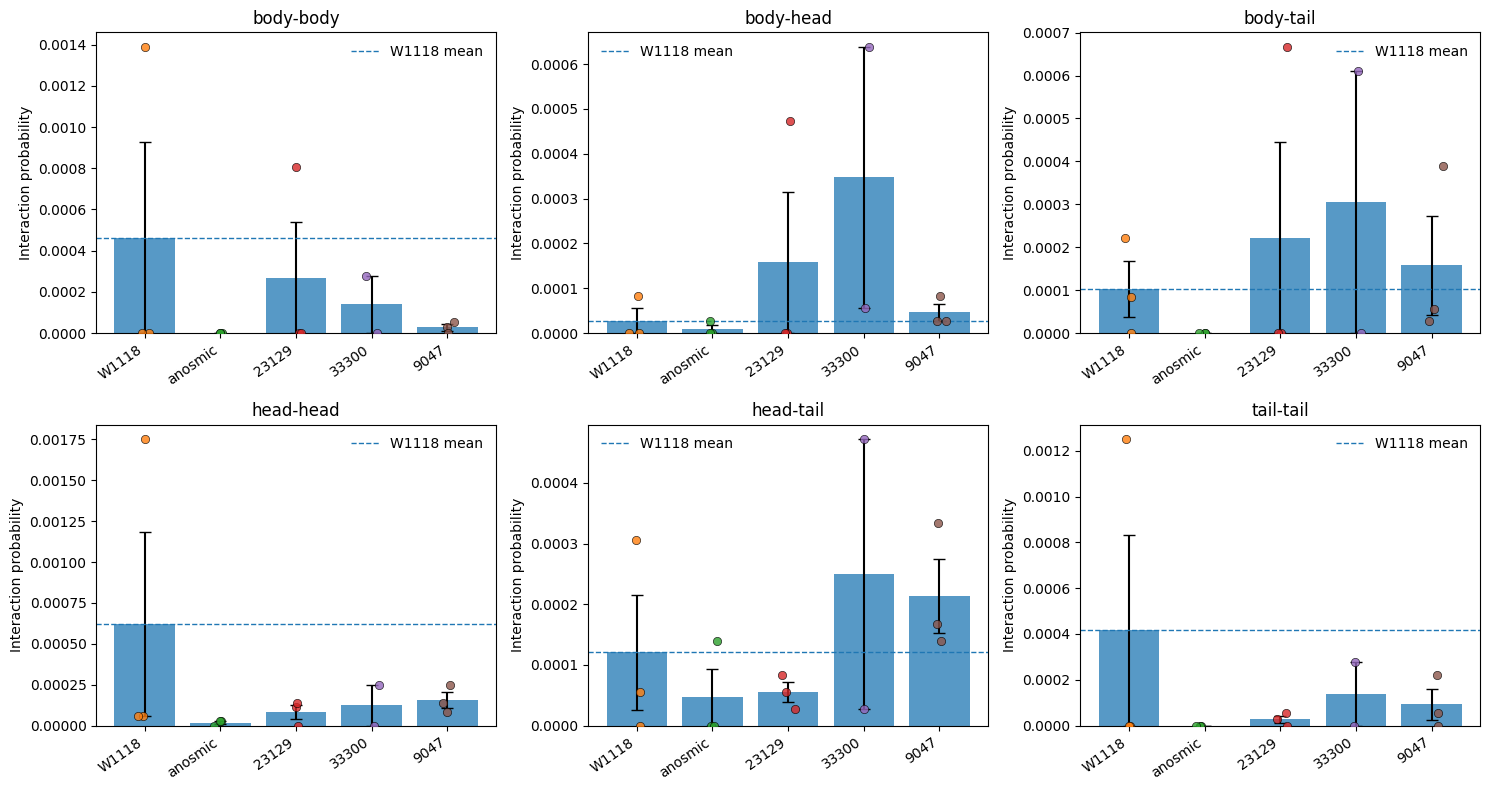

In [ ]:
interaction_types = sorted([
    col.replace("_probability_mean", "")
    for col in condition_interaction_summary.columns
    if col.endswith("_probabilitx_mean")
])


n_metrics = len(interaction_types)
n_cols = 3
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=False,
)

axes = np.array(axes).reshape(-1)

for ax, interaction_type in zip(axes, interaction_types):

    mean_col = f"{interaction_type}_probability_mean"
    sem_col = f"{interaction_type}_probability_sem"

    plot_df = (
        condition_interaction_summary
        .set_index("condition")
        .loc[CONDITIONS]
        .reset_index()
    )

    x = np.arange(len(CONDITIONS))

    ax.bar(
        x,
        plot_df[mean_col],
        yerr=plot_df[sem_col],
        capsize=4,
        alpha=0.75,
    )

    # Overlay individual video values
    raw_col = f"{interaction_type}_probability"

    for i, condition in enumerate(CONDITIONS):

        values = (
            per_video_interactions
            .loc[
                per_video_interactions["condition"] == condition,
                raw_col
            ]
            .dropna()
            .values
        )

        jitter = np.random.normal(0, 0.05, size=len(values))

        ax.scatter(
            np.full(len(values), i) + jitter,
            values,
            edgecolor="black",
            linewidth=0.5,
            alpha=0.8,
            zorder=3,
        )

    # W1118 mean reference line
    w1118_mean = plot_df.loc[
        plot_df["condition"] == REFERENCE,
        mean_col
    ].values[0]

    ax.axhline(
        w1118_mean,
        linestyle="--",
        linewidth=1,
        label="W1118 mean",
    )

    ax.set_title(interaction_type.replace("_", "-"))
    ax.set_xticks(x)
    ax.set_xticklabels(CONDITIONS, rotation=35, ha="right")
    ax.set_ylabel("Interaction probability")
    ax.legend(frameon=False)

# Hide unused axes
for ax in axes[len(interaction_types):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

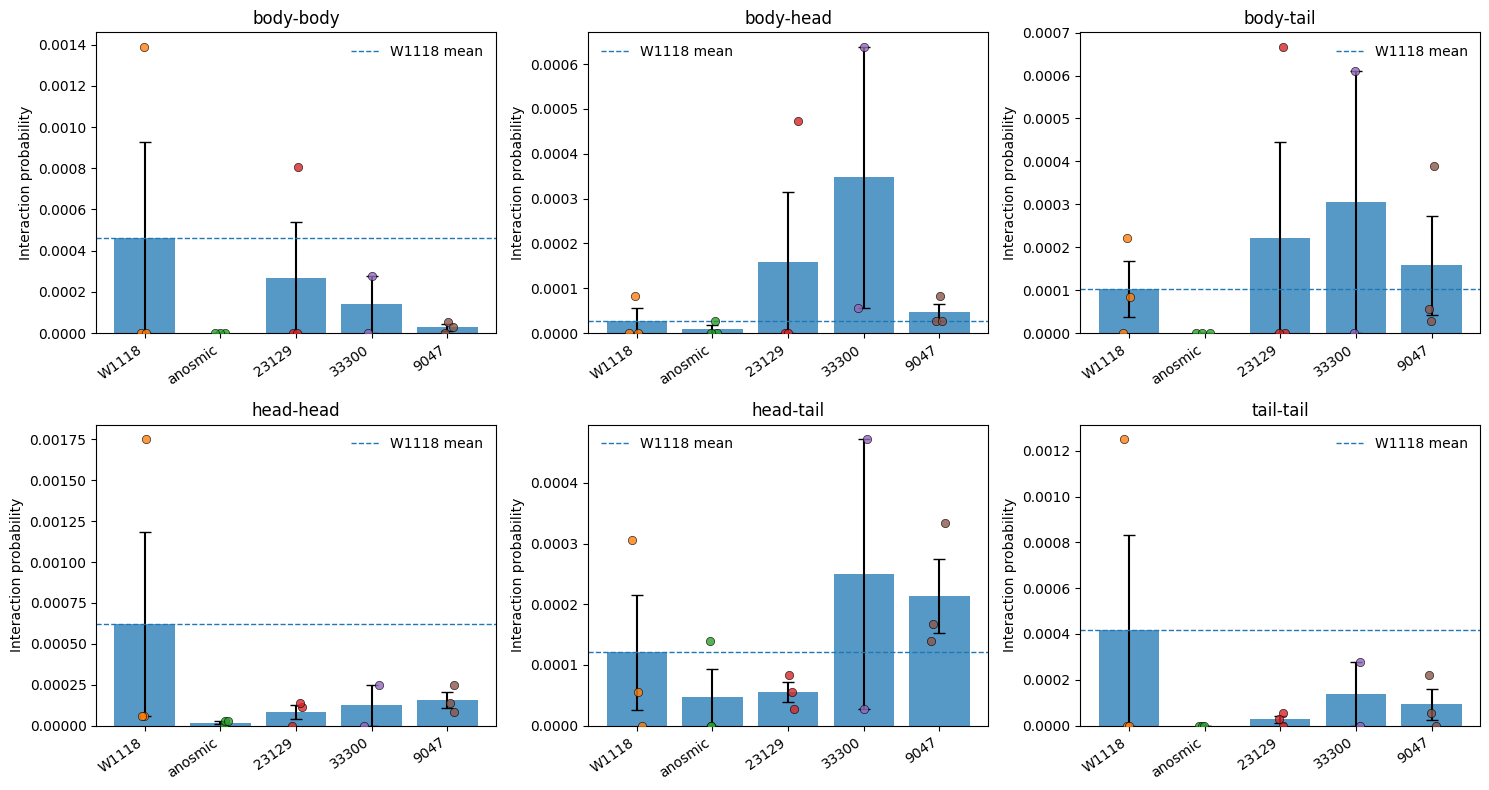

In [57]:
n_metrics = len(interaction_types)
n_cols = 3
n_rows = int(np.ceil(n_metrics / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=False,
)

axes = np.array(axes).reshape(-1)

for ax, interaction_type in zip(axes, interaction_types):

    mean_col = f"{interaction_type}_probability_mean"
    sem_col = f"{interaction_type}_probability_sem"

    plot_df = (
        condition_interaction_summary
        .set_index("condition")
        .loc[CONDITIONS]
        .reset_index()
    )

    x = np.arange(len(CONDITIONS))

    ax.bar(
        x,
        plot_df[mean_col],
        yerr=plot_df[sem_col],
        capsize=4,
        alpha=0.75,
    )

    # Overlay individual video values
    raw_col = f"{interaction_type}_probability"

    for i, condition in enumerate(CONDITIONS):

        values = (
            per_video_interactions
            .loc[
                per_video_interactions["condition"] == condition,
                raw_col
            ]
            .dropna()
            .values
        )

        jitter = np.random.normal(0, 0.05, size=len(values))

        ax.scatter(
            np.full(len(values), i) + jitter,
            values,
            edgecolor="black",
            linewidth=0.5,
            alpha=0.8,
            zorder=3,
        )

    # W1118 mean reference line
    w1118_mean = plot_df.loc[
        plot_df["condition"] == REFERENCE,
        mean_col
    ].values[0]

    ax.axhline(
        w1118_mean,
        linestyle="--",
        linewidth=1,
        label="W1118 mean",
    )

    ax.set_title(interaction_type.replace("_", "-"))
    ax.set_xticks(x)
    ax.set_xticklabels(CONDITIONS, rotation=35, ha="right")
    ax.set_ylabel("Interaction probability")
    ax.legend(frameon=False)

# Hide unused axes
for ax in axes[len(interaction_types):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [58]:
all_event_results = []
all_video_summaries = []

for condition in CONDITIONS:

    df_condition = combined_conditions[condition]

    if df_condition.empty:
        print(f"No data for {condition}")
        continue

    for file_name, df_video in df_condition.groupby("file"):

        print(f"Analysing {condition}: {file_name}")

        event_df, video_summary = analyse_one_video_interaction_dynamics(
            df=df_video,
            file_name=file_name,
            condition=condition,
        )

        if not event_df.empty:
            all_event_results.append(event_df)

        all_video_summaries.append(video_summary)


interaction_event_results = (
    pd.concat(all_event_results, ignore_index=True)
    if all_event_results else pd.DataFrame()
)

interaction_video_summary = pd.concat(
    all_video_summaries,
    ignore_index=True,
)

interaction_video_summary

Analysing W1118: 2026-03-20_td18_W1118.tracks.feather
Analysing W1118: 2026-03-20_td19_W1118.tracks.feather


/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_an

Analysing W1118: 2026-03-31_td9_W1118.tracks.feather
Analysing anosmic: 2026-06-26_td4_anosmic.tracks.feather
Analysing anosmic: 2026-06-26_td5_anosmic.tracks.feather
Analysing anosmic: 2026-06-26_td6_anosmic.tracks.feather


/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_an

Analysing 23129: 2026-03-20_td3_23129.tracks.feather
Analysing 23129: 2026-03-23_td2_23129.tracks.feather


...

/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_an

Analysing 33300: 2026-03-31_td6_33300.tracks.feather
Analysing 9047: 2026-03-31_td11_9047.tracks.feather


/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_angle = np.nanmean(movement_angles) if movement_angles else np.nan
/var/folders/vp/kct0bnpj5g9_h6x43mk9x6n00000gp/T/ipykernel_82208/3914356404.py:567: RuntimeWarning: Mean of empty slice
  mean_movement_direction_an

Analysing 9047: 2026-03-31_td3_9047.tracks.feather
Analysing 9047: 2026-04-14_td6_9047.tracks.feather


,condition,file,n_bouts,mean_average_speed_approach,mean_speed_change,mean_time_close_frames,total_time_close_frames,mean_body_direction_angle,mean_movement_direction_angle
0,W1118,2026-03-20_td18_W1118.tracks.feather,5,5.526206,-1.981963,1.000000,5,34.851303,88.892469
1,W1118,2026-03-20_td19_W1118.tracks.feather,39,3.681119,-0.648872,2.538462,99,78.071452,95.313483
2,W1118,2026-03-31_td9_W1118.tracks.feather,5,3.093488,-1.011282,1.000000,5,58.740839,74.290683
3,anosmic,2026-06-26_td4_anosmic.tracks.feather,0,NaN,NaN,NaN,0,NaN,NaN
4,anosmic,2026-06-26_td5_anosmic.tracks.feather,1,4.219324,-3.091572,1.000000,1,48.025030,89.609494
5,anosmic,2026-06-26_td6_anosmic.tracks.feather,39,NaN,NaN,461.743590,18008,38.169891,NaN
6,23129,2026-03-20_td3_23129.tracks.feather,2,10.854427,2.595146,1.000000,2,83.350224,92.411832
7,23129,2026-03-23_td2_23129.tracks.feather,21,1.587638,-0.689070,1.952381,41,77.981418,88.936387
8,23129,2026-03-31_td4_23129.tracks.feather,7,5.247333,-0.986705,1.000000,7,43.564171,62.849906
9,33300,2026-03-23_td16_33300.tracks.feather,53,1.524725,-0.485574,1.433962,76,83.638952,94.943598


In [59]:
metrics = [
    "n_bouts",
    "mean_average_speed_approach",
    "mean_speed_change",
    "mean_time_close_frames",
    "total_time_close_frames",
    "mean_body_direction_angle",
    "mean_movement_direction_angle",
]

interaction_condition_summary = (
    interaction_video_summary
    .groupby("condition")[metrics]
    .agg(["mean", "std", "sem", "count"])
)

interaction_condition_summary.columns = [
    "_".join(col)
    for col in interaction_condition_summary.columns
]

interaction_condition_summary = (
    interaction_condition_summary
    .reset_index()
    .set_index("condition")
    .loc[CONDITIONS]
    .reset_index()
)

interaction_condition_summary

,condition,n_bouts_mean,n_bouts_std,n_bouts_sem,n_bouts_count,mean_average_speed_approach_mean,mean_average_speed_approach_std,mean_average_speed_approach_sem,mean_average_speed_approach_count,mean_speed_change_mean,...,total_time_close_frames_sem,total_time_close_frames_count,mean_body_direction_angle_mean,mean_body_direction_angle_std,mean_body_direction_angle_sem,mean_body_direction_angle_count,mean_movement_direction_angle_mean,mean_movement_direction_angle_std,mean_movement_direction_angle_sem,mean_movement_direction_angle_count
0,W1118,16.333333,19.629909,11.333333,3,4.100271,1.269368,0.732870,3,-1.214039,...,31.333333,3,57.221198,21.650111,12.499697,3,86.165545,10.773422,6.220038,3
1,anosmic,13.333333,22.233608,12.836580,3,4.219324,NaN,NaN,1,-3.091572,...,6002.500007,3,43.097460,6.968636,4.927570,2,89.609494,NaN,NaN,1
2,23129,10.000000,9.848858,5.686241,3,5.896466,4.667373,2.694709,3,0.306457,...,12.251984,3,68.298604,21.588195,12.463950,3,81.399375,16.158025,9.328840,3
3,33300,28.000000,35.355339,25.000000,2,2.845711,1.868156,1.320986,2,-1.386202,...,36.500000,2,60.534535,32.674579,23.104417,2,81.603490,18.865761,13.340108,2
4,9047,17.000000,12.165525,7.023769,3,4.932142,2.888450,1.667647,3,-0.352642,...,7.965202,3,62.571923,32.512277,18.770972,3,81.700635,11.583629,6.687811,3


In [21]:
def plot_metric_by_condition(
    video_summary,
    metric,
    ylabel,
    title=None,
    condition_order=CONDITIONS,
):
    """
    Bar plot of condition means with individual video points overlaid.
    """

    plot_df = video_summary.copy()
    plot_df = plot_df[plot_df["condition"].isin(condition_order)]

    summary = (
        plot_df
        .groupby("condition")[metric]
        .agg(["mean", "sem"])
        .reindex(condition_order)
        .reset_index()
    )

    x = np.arange(len(condition_order))

    plt.figure(figsize=(8, 5))

    plt.bar(
        x,
        summary["mean"],
        yerr=summary["sem"],
        capsize=4,
        alpha=0.7,
    )

    # Add individual video points
    for i, condition in enumerate(condition_order):
        values = plot_df.loc[plot_df["condition"] == condition, metric].dropna().values

        jitter = np.random.normal(loc=0, scale=0.05, size=len(values))

        plt.scatter(
            np.full(len(values), i) + jitter,
            values,
            alpha=0.8,
            edgecolor="black",
            linewidth=0.5,
        )

    plt.xticks(x, condition_order, rotation=30, ha="right")
    plt.ylabel(ylabel)

    if title is None:
        title = metric

    plt.title(title)

    # Visual reference line for W1118 mean
    w1118_mean = summary.loc[summary["condition"] == "W1118", "mean"].values

    if len(w1118_mean) > 0 and np.isfinite(w1118_mean[0]):
        plt.axhline(
            w1118_mean[0],
            linestyle="--",
            linewidth=1,
            label="W1118 mean",
        )
        plt.legend()

    plt.tight_layout()
    plt.show()

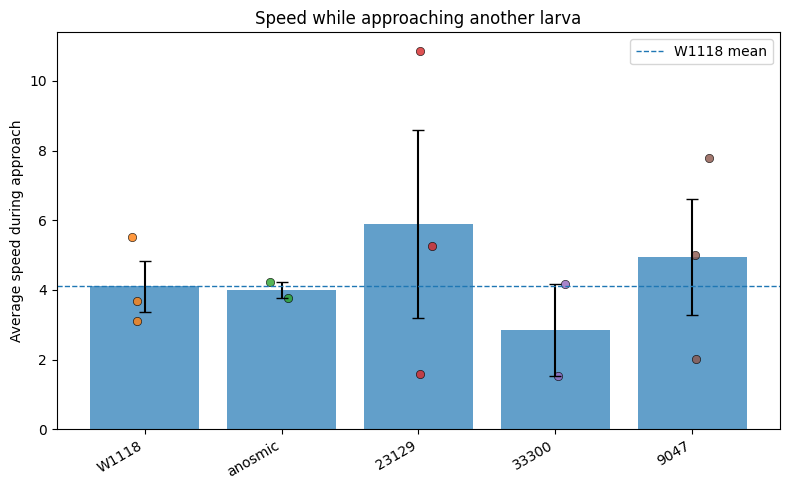

In [22]:
plot_metric_by_condition(
    interaction_video_summary,
    metric="mean_average_speed_approach",
    ylabel="Average speed during approach",
    title="Speed while approaching another larva",
)

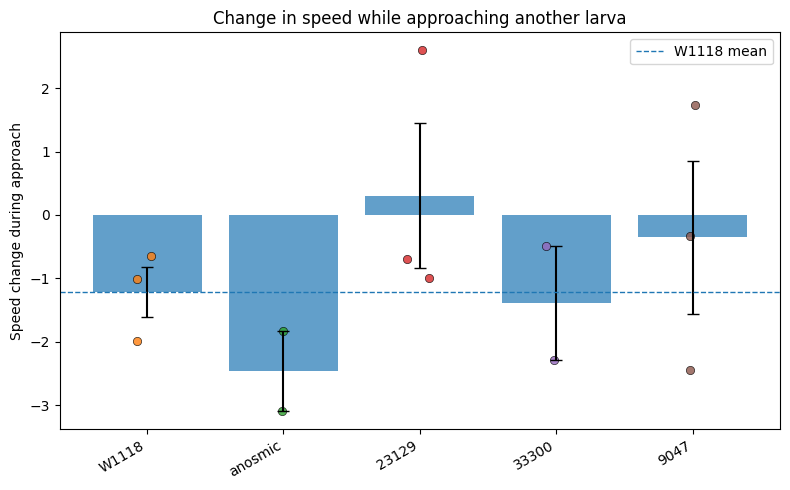

In [23]:
plot_metric_by_condition(
    interaction_video_summary,
    metric="mean_speed_change",
    ylabel="Speed change during approach",
    title="Change in speed while approaching another larva",
)

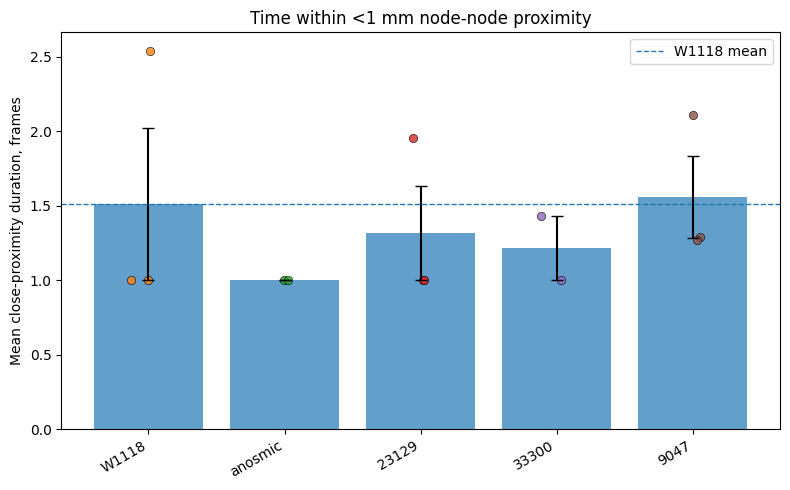

In [24]:
plot_metric_by_condition(
    interaction_video_summary,
    metric="mean_time_close_frames",
    ylabel="Mean close-proximity duration, frames",
    title="Time within <1 mm node-node proximity",
)

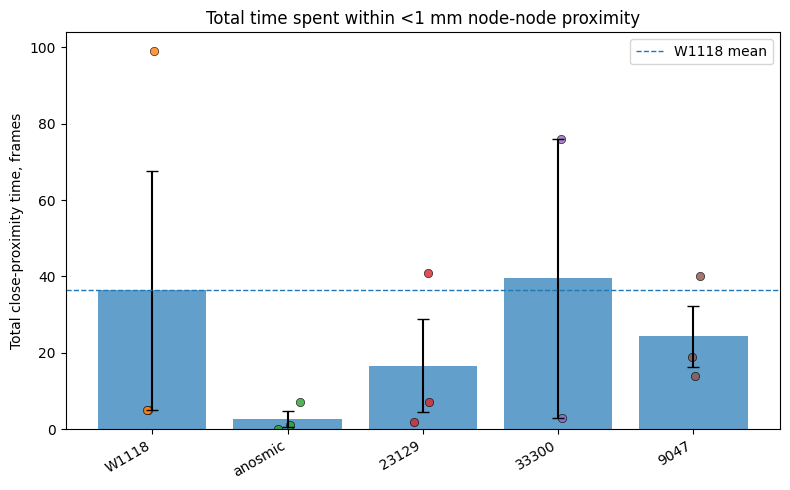

In [25]:
plot_metric_by_condition(
    interaction_video_summary,
    metric="total_time_close_frames",
    ylabel="Total close-proximity time, frames",
    title="Total time spent within <1 mm node-node proximity",
)